# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 1 — Project Setup and Raw Data Understanding

This phase treats the selected dataset as an independent raw data source. It loads and preserves the file, documents its structure, performs non-destructive quality checks, and creates a diverse visual profile. **No cleaning, encoding, scaling, feature engineering, target construction, or model training is performed in Phase 1.**

## Phase 1 Folder Structure

```text
outputs/
└── Phase_01_Project_Setup_and_Raw_Data_Understanding/
    └── Section_01_XX_Section_Title/
        └── Cell_01_XX_XX_Cell_Title/
            ├── tables/
            ├── figures/
            ├── reports/
            └── files/
```

At the end of the phase, a handoff manifest points Phase 2 to the preserved raw dataset with its anonymous audit identifier.

# Section 1.1 — Project Information and Execution Environment

**Purpose:** Define the project, select the execution environment and data source in one place, and create the complete Phase → Section → Cell folder hierarchy.

In [1]:
# Cell 1.1.1 — Configure Environment, Data Source, and Project Folders

from pathlib import Path
from datetime import datetime
import hashlib
import json
import os
import re
import shutil
import sys

# -----------------------------------------------------------------------------
# CHANGE THESE SETTINGS ONLY
# -----------------------------------------------------------------------------
EXECUTION_ENVIRONMENT = "ANACONDA"       # "COLAB", "ANACONDA", or "VSCODE"
DATA_SOURCE = "SYNTHETIC"             # "SYNTHETIC", "QUESTIONNAIRE", or "MINISTRY"
CUSTOM_DATA_PATH = None                # Example: Path("data/my_dataset.csv")
# -----------------------------------------------------------------------------

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"

ALLOWED_ENVIRONMENTS = {"COLAB", "ANACONDA", "VSCODE"}
ALLOWED_DATA_SOURCES = {"SYNTHETIC", "QUESTIONNAIRE", "MINISTRY"}

EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()
DATA_SOURCE = DATA_SOURCE.strip().upper()

if EXECUTION_ENVIRONMENT not in ALLOWED_ENVIRONMENTS:
    raise ValueError(f"EXECUTION_ENVIRONMENT must be one of {sorted(ALLOWED_ENVIRONMENTS)}")
if DATA_SOURCE not in ALLOWED_DATA_SOURCES:
    raise ValueError(f"DATA_SOURCE must be one of {sorted(ALLOWED_DATA_SOURCES)}")

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_ROOT = Path("/content/drive/MyDrive/Jaafar_MSc_Thesis")
    except ImportError:
        print("Google Colab is unavailable; using the current local directory.")
        PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE_DIR = OUTPUT_ROOT / "Phase_01_Project_Setup_and_Raw_Data_Understanding"
SHARED_DIR = PROJECT_ROOT / "shared_project_files"

for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, SHARED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RANDOM_STATE = 42


def safe_name(text):
    text = str(text).strip().replace("—", "-").replace("–", "-")
    text = re.sub(r"[^\w\-]+", "_", text, flags=re.UNICODE)
    return re.sub(r"_+", "_", text).strip("_") or "Unnamed"


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    section_folder = PHASE_DIR / safe_name(f"Section_{section_number}_{section_title}")
    cell_folder = section_folder / safe_name(f"Cell_{cell_number}_{cell_title}")
    folders = {
        "cell": cell_folder,
        "tables": cell_folder / "tables",
        "figures": cell_folder / "figures",
        "reports": cell_folder / "reports",
        "files": cell_folder / "files",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders

CELL_FOLDERS = create_cell_folders(
    "01_01",
    "Project_Information_and_Execution_Environment",
    "01_01_01",
    "Configure_Environment_Data_Source_and_Project_Folders",
)

project_configuration = {
    "project_title": PROJECT_TITLE,
    "programme": PROGRAMME,
    "student_name": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "data_source": DATA_SOURCE,
    "custom_data_path": str(CUSTOM_DATA_PATH) if CUSTOM_DATA_PATH else None,
    "project_root": str(PROJECT_ROOT),
    "data_directory": str(DATA_DIR),
    "output_directory": str(OUTPUT_ROOT),
    "phase_directory": str(PHASE_DIR),
    "shared_directory": str(SHARED_DIR),
    "random_state": RANDOM_STATE,
    "run_timestamp": RUN_TIMESTAMP,
}

with (CELL_FOLDERS["reports"] / "01_01_01_project_configuration.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(project_configuration, file, ensure_ascii=False, indent=2)

with (SHARED_DIR / "project_config.json").open("w", encoding="utf-8") as file:
    json.dump(project_configuration, file, ensure_ascii=False, indent=2)

print("Execution environment:", EXECUTION_ENVIRONMENT)
print("Selected data source:", DATA_SOURCE)
print("Project root:", PROJECT_ROOT)
print("Phase output directory:", PHASE_DIR)

Execution environment: ANACONDA
Selected data source: SYNTHETIC
Project root: C:\Users\User\Desktop\All
Phase output directory: C:\Users\User\Desktop\All\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding


# Section 1.2 — Install Required Libraries

**Purpose:** Check the libraries required by Phase 1 and install only packages that are missing from the selected environment.

In [2]:
# Cell 1.2.1 — Check and Install Missing Libraries

import importlib.util
import subprocess

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "openpyxl": "openpyxl",
}

installation_rows = []
for import_name, package_name in required_packages.items():
    installed = importlib.util.find_spec(import_name) is not None
    if installed:
        status = "Already installed"
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        status = "Installed during this run"
    installation_rows.append({
        "import_name": import_name,
        "package_name": package_name,
        "status": status,
    })

import pandas as pd

CELL_FOLDERS = create_cell_folders(
    "01_02", "Install_Required_Libraries", "01_02_01", "Check_and_Install_Missing_Libraries"
)
installation_report = pd.DataFrame(installation_rows)
installation_report.to_csv(
    CELL_FOLDERS["tables"] / "01_02_01_library_installation_report.csv",
    index=False,
    encoding="utf-8-sig",
)
installation_report.to_excel(
    CELL_FOLDERS["tables"] / "01_02_01_library_installation_report.xlsx",
    index=False,
)
display(installation_report)

,import_name,package_name,status
0,pandas,pandas,Already installed
1,numpy,numpy,Already installed
2,matplotlib,matplotlib,Already installed
3,scipy,scipy,Already installed
4,openpyxl,openpyxl,Already installed


# Section 1.3 — Import Libraries, Visual Identity, and Reusable Functions

**Purpose:** Import the required libraries, define a distinctive Bahrain Thesis visual identity, and create reusable functions for exports, provenance, and visualisation.

In [3]:
# Cell 1.3.1 — Import Libraries and Define the Bahrain Thesis Visual Identity

import math
import random
import warnings
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

warnings.filterwarnings("default")
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

THEME = {
    "maroon": "#6B1E32",
    "deep_maroon": "#43101F",
    "gold": "#D4A64A",
    "teal": "#237A7A",
    "coral": "#D96850",
    "indigo": "#525B92",
    "sage": "#7A9B76",
    "sand": "#D9C7A3",
    "warm_white": "#F7F4EF",
    "charcoal": "#2E3035",
    "muted": "#70737A",
    "light_grid": "#D9D4CC",
}

CLASS_COLOURS = {
    "Low": THEME["coral"],
    "Medium": THEME["gold"],
    "High": THEME["teal"],
}

mpl.rcParams.update({
    "figure.facecolor": THEME["warm_white"],
    "axes.facecolor": THEME["warm_white"],
    "axes.edgecolor": THEME["charcoal"],
    "axes.labelcolor": THEME["charcoal"],
    "axes.titlecolor": THEME["deep_maroon"],
    "text.color": THEME["charcoal"],
    "xtick.color": THEME["charcoal"],
    "ytick.color": THEME["charcoal"],
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 17,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": THEME["light_grid"],
    "grid.alpha": 0.55,
    "legend.frameon": False,
})

CELL_FOLDERS = create_cell_folders(
    "01_03",
    "Import_Libraries_Visual_Identity_and_Reusable_Functions",
    "01_03_01",
    "Import_Libraries_and_Define_the_Bahrain_Thesis_Visual_Identity",
)

library_versions = pd.DataFrame({
    "library": ["Python", "pandas", "numpy", "matplotlib", "scipy"],
    "version": [
        sys.version.split()[0],
        pd.__version__,
        np.__version__,
        mpl.__version__,
        __import__("scipy").__version__,
    ],
})
visual_theme_table = pd.DataFrame(
    [{"theme_element": key, "hex_colour": value} for key, value in THEME.items()]
)

library_versions.to_csv(
    CELL_FOLDERS["tables"] / "01_03_01_library_versions.csv",
    index=False,
    encoding="utf-8-sig",
)
visual_theme_table.to_csv(
    CELL_FOLDERS["tables"] / "01_03_01_visual_theme.csv",
    index=False,
    encoding="utf-8-sig",
)
with (CELL_FOLDERS["reports"] / "01_03_01_visual_theme.json").open("w", encoding="utf-8") as file:
    json.dump({"theme": THEME, "class_colours": CLASS_COLOURS}, file, indent=2)

display(library_versions)
display(visual_theme_table)

,library,version
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.1.3
3,matplotlib,3.10.0
4,scipy,1.15.3


,theme_element,hex_colour
0,maroon,#6B1E32
1,deep_maroon,#43101F
2,gold,#D4A64A
3,teal,#237A7A
4,coral,#D96850
5,indigo,#525B92
6,sage,#7A9B76
7,sand,#D9C7A3
8,warm_white,#F7F4EF
9,charcoal,#2E3035


In [4]:
# Cell 1.3.2 — Define Reusable Export, Provenance, and Plot Functions

SUPPORTED_FILE_TYPES = {".csv", ".xlsx", ".xls"}


def save_dataframe(dataframe, folders, file_stem, index=False, excel=True):
    saved = []
    csv_path = folders["tables"] / f"{file_stem}.csv"
    dataframe.to_csv(csv_path, index=index, encoding="utf-8-sig")
    saved.append(csv_path)
    if excel:
        xlsx_path = folders["tables"] / f"{file_stem}.xlsx"
        dataframe.to_excel(xlsx_path, index=index)
        saved.append(xlsx_path)
    return saved


def save_json_report(data, folders, file_stem):
    path = folders["reports"] / f"{file_stem}.json"
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def save_figure(figure, folders, file_stem):
    path = folders["figures"] / f"{file_stem}.png"
    figure.savefig(path, dpi=300, bbox_inches="tight", facecolor=figure.get_facecolor())
    return path


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def load_tabular_file(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")
    return pd.read_excel(path)


def normalise_header_for_lookup(header):
    text = str(header).strip().lower()
    text = text.replace("’", "'").replace("`", "'")
    text = text.replace("–", "-").replace("—", "-")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def locate_column(dataframe, possible_names):
    lookup = {normalise_header_for_lookup(column): column for column in dataframe.columns}
    for possible_name in possible_names:
        key = normalise_header_for_lookup(possible_name)
        if key in lookup:
            return lookup[key]
    return None


def add_branding(axis, title, subtitle=None, footer=None):
    axis.set_title(title, loc="left", pad=18, color=THEME["deep_maroon"], fontweight="bold")
    if subtitle:
        axis.text(
            0, 1.02, subtitle,
            transform=axis.transAxes,
            ha="left", va="bottom",
            fontsize=10, color=THEME["muted"],
        )
    footer_text = footer or "MSc Artificial Intelligence — Bahrain Polytechnic"
    axis.text(
        0, -0.16, footer_text,
        transform=axis.transAxes,
        ha="left", va="top",
        fontsize=8.5, color=THEME["muted"],
    )


def value_labels(axis, orientation="vertical", suffix=""):
    if orientation == "vertical":
        for patch in axis.patches:
            height = patch.get_height()
            if np.isfinite(height):
                axis.text(
                    patch.get_x() + patch.get_width() / 2,
                    height,
                    f"{height:,.0f}{suffix}",
                    ha="center", va="bottom", fontsize=9, color=THEME["charcoal"],
                )
    else:
        for patch in axis.patches:
            width = patch.get_width()
            if np.isfinite(width):
                axis.text(
                    width,
                    patch.get_y() + patch.get_height() / 2,
                    f" {width:,.0f}{suffix}",
                    ha="left", va="center", fontsize=9, color=THEME["charcoal"],
                )


def resolve_manifest_dataset(manifest_path):
    with Path(manifest_path).open("r", encoding="utf-8") as file:
        manifest = json.load(file)
    candidates = [
        manifest.get("primary_input_for_phase_1"),
        manifest.get("alternative_excel_input"),
    ]
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return Path(candidate), manifest
    file_names = [Path(candidate).name for candidate in candidates if candidate]
    for file_name in file_names:
        matches = list(PROJECT_ROOT.rglob(file_name))
        if matches:
            return matches[0], manifest
    raise FileNotFoundError("The Phase 0 manifest was found, but its dataset could not be located.")


CELL_FOLDERS = create_cell_folders(
    "01_03",
    "Import_Libraries_Visual_Identity_and_Reusable_Functions",
    "01_03_02",
    "Define_Reusable_Export_Provenance_and_Plot_Functions",
)

function_catalogue = pd.DataFrame({
    "function": [
        "save_dataframe", "save_json_report", "save_figure", "file_sha256",
        "load_tabular_file", "locate_column", "add_branding", "value_labels",
        "resolve_manifest_dataset",
    ],
    "purpose": [
        "Save tables as CSV and Excel", "Save structured JSON reports",
        "Save high-resolution figures", "Calculate a source-file checksum",
        "Load CSV or Excel without cleaning", "Find raw columns without renaming them",
        "Apply the thesis visual identity", "Add readable data labels",
        "Read the Phase 0 handoff package",
    ],
})
save_dataframe(function_catalogue, CELL_FOLDERS, "01_03_02_function_catalogue")
display(function_catalogue)

,function,purpose
0,save_dataframe,Save tables as CSV and Excel
1,save_json_report,Save structured JSON reports
2,save_figure,Save high-resolution figures
3,file_sha256,Calculate a source-file checksum
4,load_tabular_file,Load CSV or Excel without cleaning
5,locate_column,Find raw columns without renaming them
6,add_branding,Apply the thesis visual identity
7,value_labels,Add readable data labels
8,resolve_manifest_dataset,Read the Phase 0 handoff package


# Section 1.4 — Data Source Selection, Collection, and Loading

**Purpose:** Resolve the selected source, load it as an independent raw dataset, preserve the exact original file, and create a separate anonymous audit identifier without altering source values.

In [5]:
# Cell 1.4.1 — Resolve the Selected Dataset Source

CELL_FOLDERS = create_cell_folders(
    "01_04", "Data_Source_Selection_Collection_and_Loading",
    "01_04_01", "Resolve_the_Selected_Dataset_Source",
)

source_resolution_method = None
source_manifest = None

if CUSTOM_DATA_PATH is not None:
    SOURCE_FILE = Path(CUSTOM_DATA_PATH)
    if not SOURCE_FILE.is_absolute():
        SOURCE_FILE = PROJECT_ROOT / SOURCE_FILE
    source_resolution_method = "CUSTOM_DATA_PATH"

elif DATA_SOURCE == "SYNTHETIC":
    manifest_matches = list(PROJECT_ROOT.rglob("phase_00_handoff_manifest.json"))
    if manifest_matches:
        SOURCE_FILE, source_manifest = resolve_manifest_dataset(manifest_matches[0])
        source_resolution_method = "PHASE_0_HANDOFF_MANIFEST"
    else:
        synthetic_matches = list(PROJECT_ROOT.rglob("synthetic_questionnaire_results_2500_records.csv"))
        if not synthetic_matches:
            synthetic_matches = list(PROJECT_ROOT.rglob("synthetic_questionnaire_results*.xlsx"))
        if not synthetic_matches:
            raise FileNotFoundError(
                "Synthetic data was selected, but no Phase 0 handoff manifest or synthetic dataset was found."
            )
        SOURCE_FILE = synthetic_matches[0]
        source_resolution_method = "SYNTHETIC_FILE_SEARCH"

else:
    keywords = {
        "QUESTIONNAIRE": ["questionnaire", "survey", "response"],
        "MINISTRY": ["ministry", "moe", "official"],
    }[DATA_SOURCE]
    candidates = [
        path for path in DATA_DIR.iterdir()
        if path.is_file() and path.suffix.lower() in SUPPORTED_FILE_TYPES
    ]
    preferred = [
        path for path in candidates
        if any(keyword in path.name.lower() for keyword in keywords)
    ]
    candidates = preferred or candidates
    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected exactly one {DATA_SOURCE} file in {DATA_DIR}. "
            f"Found {len(candidates)}. Set CUSTOM_DATA_PATH explicitly."
        )
    SOURCE_FILE = candidates[0]
    source_resolution_method = "DATA_DIRECTORY_SEARCH"

if not SOURCE_FILE.exists():
    raise FileNotFoundError(f"Dataset not found: {SOURCE_FILE}")
if SOURCE_FILE.suffix.lower() not in SUPPORTED_FILE_TYPES:
    raise ValueError(f"Unsupported dataset type: {SOURCE_FILE.suffix}")

source_registry = {
    "data_source": DATA_SOURCE,
    "source_file": str(SOURCE_FILE.resolve()),
    "source_resolution_method": source_resolution_method,
    "phase_0_manifest_used": source_manifest is not None,
    "source_file_sha256": file_sha256(SOURCE_FILE),
    "resolved_at": datetime.now().isoformat(),
}
if source_manifest:
    source_registry["phase_0_manifest"] = source_manifest

save_json_report(source_registry, CELL_FOLDERS, "01_04_01_source_registry")
print("Data source:", DATA_SOURCE)
print("Resolved dataset:", SOURCE_FILE)
print("Resolution method:", source_resolution_method)

Data source: SYNTHETIC
Resolved dataset: C:\Users\User\Desktop\All\data\synthetic_questionnaire_results_2500_records.csv
Resolution method: PHASE_0_HANDOFF_MANIFEST


In [6]:
# Cell 1.4.2 — Load the Raw Dataset and Create the Anonymous Audit ID

CELL_FOLDERS = create_cell_folders(
    "01_04", "Data_Source_Selection_Collection_and_Loading",
    "01_04_02", "Load_the_Raw_Dataset_and_Create_the_Anonymous_Audit_ID",
)

original_data = load_tabular_file(SOURCE_FILE)
if original_data.empty:
    raise ValueError("The selected dataset is empty.")

# original_data remains an exact representation of the selected input file.
raw_data = original_data.copy()
raw_data.insert(
    0,
    "student_record_id",
    [f"STU{number:06d}" for number in range(1, len(raw_data) + 1)],
)
raw_data.insert(1, "source_row_number", np.arange(2, len(raw_data) + 2))

loading_summary = {
    "data_source": DATA_SOURCE,
    "source_file_name": SOURCE_FILE.name,
    "source_file_sha256": file_sha256(SOURCE_FILE),
    "original_rows": int(original_data.shape[0]),
    "original_columns": int(original_data.shape[1]),
    "audit_rows": int(raw_data.shape[0]),
    "audit_columns": int(raw_data.shape[1]),
    "technical_columns_added": ["student_record_id", "source_row_number"],
    "source_values_changed": 0,
    "records_deleted": 0,
    "preprocessing_applied": False,
    "loaded_at": datetime.now().isoformat(),
}

save_json_report(loading_summary, CELL_FOLDERS, "01_04_02_loading_summary")
preview = pd.concat([
    raw_data.head(5).assign(preview_position="First records"),
    raw_data.tail(5).assign(preview_position="Last records"),
], ignore_index=True)
save_dataframe(preview, CELL_FOLDERS, "01_04_02_raw_dataset_preview")

print("Original dataset shape:", original_data.shape)
print("Audit dataset shape:", raw_data.shape)
display(preview)

Original dataset shape: (2500, 25)
Audit dataset shape: (2500, 27)


,student_record_id,source_row_number,Family ID,Father Alive,Mother Alive,Father's Education,Mother's Education,Father's Job,Mother's Job,Marital Status,Family Income,Number of Family Members,Gender,School Type,Stage,Grade,Tutoring Support,Social Activities,Chronic Disease,First Semester Average,Second Semester Average,Difference (Semester 2 - Semester 1),Daily Smart Device Usage,Other Influencing Factors,Additional Suggestions,Response Language,Submission Date,preview_position
0,STU000001,2,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Female,Private,Primary,First,No,Yes,No,97.9,100.0,2.1,1 - 3 hours,قلة النوم وتنظيم الوقت,NaN,Arabic,2026-07-10 11:51:36,First records
1,STU000002,3,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Private,Primary,Sixth,Yes,Yes,No,99.3,97.9,-1.4,Less than an hour,الأصدقاء والبيئة الاجتماعية,NaN,Arabic,2026-07-15 21:13:30,First records
2,STU000003,4,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Government,Secondary,Third,Yes,No,No,95.4,95.2,-0.2,More than 5 hours,توفير مكان هادئ ومناسب للدراسة,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,Arabic,2026-07-14 20:36:42,First records
3,STU000004,5,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Female,Government,Primary,First,Yes,Yes,No,90.0,89.5,-0.5,3 - 5 hours,الاستخدام المفرط للألعاب الإلكترونية,تعزيز التواصل بين المدرسة وأولياء الأمور,Arabic,2026-07-16 15:28:04,First records
4,STU000005,6,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Male,Government,Primary,Fourth,Yes,Yes,No,70.6,70.3,-0.3,1 - 3 hours,الاستخدام المفرط للألعاب الإلكترونية,توفير حصص تقوية بأسعار مناسبة,Arabic,2026-07-18 10:03:08,First records
5,STU002496,2497,1234,Yes,No,Diploma,Diploma,Employed,Employed,Widower,300 – 700 BHD,4,Female,Government,Primary,First,Yes,Yes,No,92.7,93.9,1.2,3 - 5 hours,NaN,مراعاة الفروق الفردية وصعوبات التعلم,Arabic,2026-07-12 01:35:33,Last records
6,STU002497,2498,1235,Yes,Yes,Intermediate,Diploma,Employed,Unemployed,Married,300 – 700 BHD,4,Male,Government,Intermediate,Third,Yes,Yes,No,76.1,76.1,0.0,3 - 5 hours,لا,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,Arabic,2026-07-11 11:18:59,Last records
7,STU002498,2499,1236,Yes,Yes,Diploma,Bachelor's,Employed,Unemployed,Married,700 – 1000 BHD,2,Female,Government,Primary,Third,No,Yes,Yes,92.9,92.5,-0.4,Less than an hour,الأصدقاء والبيئة الاجتماعية,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,Arabic,2026-07-18 10:19:19,Last records
8,STU002499,2500,1237,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,4,Male,Government,Primary,Third,Yes,Yes,No,92.9,89.7,-3.2,1 - 3 hours,لا,تطوير أساليب التدريس والتقييم,Arabic,2026-07-11 19:18:31,Last records
9,STU002500,2501,1238,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,700 – 1000 BHD,4,Female,Government,Intermediate,First,Yes,No,No,83.7,88.3,4.6,3 - 5 hours,الحالة النفسية والدافعية للتعلم,تعزيز التواصل بين المدرسة وأولياء الأمور,Arabic,2026-07-11 15:58:36,Last records


In [7]:
# Cell 1.4.3 — Preserve the Exact Source File and Raw Audit Dataset

CELL_FOLDERS = create_cell_folders(
    "01_04", "Data_Source_Selection_Collection_and_Loading",
    "01_04_03", "Preserve_the_Exact_Source_File_and_Raw_Audit_Dataset",
)

source_copy = CELL_FOLDERS["files"] / f"01_04_03_exact_source_copy{SOURCE_FILE.suffix.lower()}"
shutil.copy2(SOURCE_FILE, source_copy)

original_csv = CELL_FOLDERS["files"] / "01_04_03_original_dataset_exact_values.csv"
original_data.to_csv(original_csv, index=False, encoding="utf-8-sig")

raw_audit_csv = CELL_FOLDERS["files"] / "01_04_03_raw_dataset_with_audit_id.csv"
raw_audit_xlsx = CELL_FOLDERS["files"] / "01_04_03_raw_dataset_with_audit_id.xlsx"
raw_data.to_csv(raw_audit_csv, index=False, encoding="utf-8-sig")
raw_data.to_excel(raw_audit_xlsx, index=False)

preservation_report = pd.DataFrame([
    {"file_role": "Exact source copy", "path": str(source_copy), "sha256": file_sha256(source_copy)},
    {"file_role": "Exact source values as CSV", "path": str(original_csv), "sha256": file_sha256(original_csv)},
    {"file_role": "Raw audit dataset CSV", "path": str(raw_audit_csv), "sha256": file_sha256(raw_audit_csv)},
    {"file_role": "Raw audit dataset Excel", "path": str(raw_audit_xlsx), "sha256": file_sha256(raw_audit_xlsx)},
])
save_dataframe(preservation_report, CELL_FOLDERS, "01_04_03_data_preservation_report")
display(preservation_report)

,file_role,path,sha256
0,Exact source copy,C:\Users\User\Desktop\All\outputs\Phase_01_Pro...,f58b5739d3b884d64b90680b25b73a5435c9cde2f68c7a...
1,Exact source values as CSV,C:\Users\User\Desktop\All\outputs\Phase_01_Pro...,f58b5739d3b884d64b90680b25b73a5435c9cde2f68c7a...
2,Raw audit dataset CSV,C:\Users\User\Desktop\All\outputs\Phase_01_Pro...,c4c7a746a0872c32f65b6b30c07cc4c0388f07be9896a6...
3,Raw audit dataset Excel,C:\Users\User\Desktop\All\outputs\Phase_01_Pro...,8c45b46146e07b8c17923b22c3fc86b91dcdba4baea8a9...


# Section 1.5 — Data Dictionary and Schema Documentation

**Purpose:** Document the exact observed schema and compare it with the approved questionnaire structure. Phase 1 reports differences but does not rename or correct columns.

In [8]:
# Cell 1.5.1 — Create the Approved Questionnaire Data Dictionary

CELL_FOLDERS = create_cell_folders(
    "01_05", "Data_Dictionary_and_Schema_Documentation",
    "01_05_01", "Create_the_Approved_Questionnaire_Data_Dictionary",
)

approved_rows = [
    ["Family ID", "Group identifier", "Family number; repetition allowed", "Grouping only"],
    ["Father Alive", "Binary categorical", "Yes / No", "Predictor"],
    ["Mother Alive", "Binary categorical", "Yes / No", "Predictor"],
    ["Father's Education", "Ordinal categorical", "Primary to PhD", "Predictor"],
    ["Mother's Education", "Ordinal categorical", "Primary to PhD", "Predictor"],
    ["Father's Job", "Nominal categorical", "Employed / Unemployed / Retired / Self-employed", "Predictor"],
    ["Mother's Job", "Nominal categorical", "Employed / Unemployed / Retired / Self-employed", "Predictor"],
    ["Marital Status", "Nominal categorical", "Married / Separated / Widow / Widower / Both parents deceased", "Predictor"],
    ["Family Income", "Ordinal categorical", "Four ordered BHD categories", "Predictor"],
    ["Number of Family Members", "Integer numeric", "Positive whole number", "Renamed in Phase 2"],
    ["Gender", "Binary categorical", "Male / Female", "Predictor"],
    ["School Type", "Binary categorical", "Private / Government", "Predictor"],
    ["Stage", "Ordinal categorical", "Primary / Intermediate / Secondary", "Used in Phase 2"],
    ["Grade", "Ordinal categorical", "First to Sixth according to Stage", "Used in Phase 2"],
    ["Tutoring Support", "Binary categorical", "Yes / No", "Predictor"],
    ["Social Activities", "Binary categorical", "Yes / No", "Predictor"],
    ["Chronic Disease", "Binary categorical", "Yes / No", "Predictor"],
    ["First Semester Average", "Decimal numeric", "0 to 100", "Target source in Phase 2"],
    ["Second Semester Average", "Decimal numeric", "0 to 100", "Excluded from model"],
    ["Difference (Semester 2 - Semester 1)", "Decimal numeric", "Second minus first", "Excluded from model"],
    ["Daily Smart Device Usage", "Ordinal categorical", "Four ordered time categories", "Predictor"],
    ["Other Influencing Factors", "Optional open text", "Arabic or English text", "Separate Phase 9"],
    ["Additional Suggestions", "Optional open text", "Arabic or English text", "Separate Phase 9"],
    ["Response Language", "Binary categorical", "Arabic / English", "Excluded from model"],
    ["Submission Date", "Date and time", "Questionnaire submission timestamp", "Excluded from model"],
]

approved_data_dictionary = pd.DataFrame(
    approved_rows,
    columns=["column_name", "data_type", "accepted_values_or_range", "planned_role"],
)
save_dataframe(approved_data_dictionary, CELL_FOLDERS, "01_05_01_approved_data_dictionary")
display(approved_data_dictionary)

,column_name,data_type,accepted_values_or_range,planned_role
0,Family ID,Group identifier,Family number; repetition allowed,Grouping only
1,Father Alive,Binary categorical,Yes / No,Predictor
2,Mother Alive,Binary categorical,Yes / No,Predictor
3,Father's Education,Ordinal categorical,Primary to PhD,Predictor
4,Mother's Education,Ordinal categorical,Primary to PhD,Predictor
5,Father's Job,Nominal categorical,Employed / Unemployed / Retired / Self-employed,Predictor
6,Mother's Job,Nominal categorical,Employed / Unemployed / Retired / Self-employed,Predictor
7,Marital Status,Nominal categorical,Married / Separated / Widow / Widower / Both p...,Predictor
8,Family Income,Ordinal categorical,Four ordered BHD categories,Predictor
9,Number of Family Members,Integer numeric,Positive whole number,Renamed in Phase 2


In [9]:
# Cell 1.5.2 — Compare the Observed Schema with the Approved Schema

CELL_FOLDERS = create_cell_folders(
    "01_05", "Data_Dictionary_and_Schema_Documentation",
    "01_05_02", "Compare_the_Observed_Schema_with_the_Approved_Schema",
)

expected_columns = approved_data_dictionary["column_name"].tolist()
observed_columns = original_data.columns.tolist()

schema_rows = []
for position in range(max(len(expected_columns), len(observed_columns))):
    expected = expected_columns[position] if position < len(expected_columns) else pd.NA
    observed = observed_columns[position] if position < len(observed_columns) else pd.NA
    schema_rows.append({
        "position": position + 1,
        "expected_column": expected,
        "observed_column": observed,
        "exact_match": expected == observed,
    })

schema_comparison = pd.DataFrame(schema_rows)
missing_expected_columns = [column for column in expected_columns if column not in observed_columns]
unexpected_columns = [column for column in observed_columns if column not in expected_columns]

schema_summary = pd.DataFrame([
    {"measure": "Expected columns", "value": len(expected_columns)},
    {"measure": "Observed columns", "value": len(observed_columns)},
    {"measure": "Exact name-and-order match", "value": expected_columns == observed_columns},
    {"measure": "Missing expected columns", "value": len(missing_expected_columns)},
    {"measure": "Unexpected columns", "value": len(unexpected_columns)},
])

save_dataframe(schema_comparison, CELL_FOLDERS, "01_05_02_schema_comparison")
save_dataframe(schema_summary, CELL_FOLDERS, "01_05_02_schema_summary")
save_json_report({
    "missing_expected_columns": missing_expected_columns,
    "unexpected_columns": unexpected_columns,
    "exact_name_and_order_match": expected_columns == observed_columns,
}, CELL_FOLDERS, "01_05_02_schema_differences")

display(schema_summary)
display(schema_comparison)

,measure,value
0,Expected columns,25
1,Observed columns,25
2,Exact name-and-order match,True
3,Missing expected columns,0
4,Unexpected columns,0


,position,expected_column,observed_column,exact_match
0,1,Family ID,Family ID,True
1,2,Father Alive,Father Alive,True
2,3,Mother Alive,Mother Alive,True
3,4,Father's Education,Father's Education,True
4,5,Mother's Education,Mother's Education,True
5,6,Father's Job,Father's Job,True
6,7,Mother's Job,Mother's Job,True
7,8,Marital Status,Marital Status,True
8,9,Family Income,Family Income,True
9,10,Number of Family Members,Number of Family Members,True


# Section 1.6 — Raw Data Description

**Purpose:** Describe the dataset exactly as received, including shape, data types, numeric summaries, category frequencies, family grouping, and temporal coverage.

In [10]:
# Cell 1.6.1 — Create Dataset Overview and Column Profile

CELL_FOLDERS = create_cell_folders(
    "01_06", "Raw_Data_Description",
    "01_06_01", "Create_Dataset_Overview_and_Column_Profile",
)

column_profile = pd.DataFrame({
    "column_name": original_data.columns,
    "pandas_dtype": [str(original_data[column].dtype) for column in original_data.columns],
    "non_missing_count": [int(original_data[column].notna().sum()) for column in original_data.columns],
    "missing_count": [int(original_data[column].isna().sum()) for column in original_data.columns],
    "missing_percentage": [round(original_data[column].isna().mean() * 100, 2) for column in original_data.columns],
    "unique_non_missing_values": [int(original_data[column].nunique(dropna=True)) for column in original_data.columns],
})

dataset_overview = pd.DataFrame([
    {"measure": "Data source", "value": DATA_SOURCE},
    {"measure": "Number of records", "value": len(original_data)},
    {"measure": "Number of source columns", "value": len(original_data.columns)},
    {"measure": "Rows with at least one missing value", "value": int(original_data.isna().any(axis=1).sum())},
    {"measure": "Columns containing missing values", "value": int(original_data.isna().any().sum())},
    {"measure": "Exact duplicate source rows", "value": int(original_data.duplicated().sum())},
])

save_dataframe(dataset_overview, CELL_FOLDERS, "01_06_01_dataset_overview")
save_dataframe(column_profile, CELL_FOLDERS, "01_06_01_column_profile")
display(dataset_overview)
display(column_profile)

,measure,value
0,Data source,SYNTHETIC
1,Number of records,2500
2,Number of source columns,25
3,Rows with at least one missing value,1115
4,Columns containing missing values,2
5,Exact duplicate source rows,0


,column_name,pandas_dtype,non_missing_count,missing_count,missing_percentage,unique_non_missing_values
0,Family ID,int64,2500,0,0.00,1238
1,Father Alive,object,2500,0,0.00,2
2,Mother Alive,object,2500,0,0.00,2
3,Father's Education,object,2500,0,0.00,7
4,Mother's Education,object,2500,0,0.00,5
5,Father's Job,object,2500,0,0.00,4
6,Mother's Job,object,2500,0,0.00,4
7,Marital Status,object,2500,0,0.00,4
8,Family Income,object,2500,0,0.00,4
9,Number of Family Members,int64,2500,0,0.00,8


In [11]:
# Cell 1.6.2 — Create Numeric and Categorical Descriptive Statistics

CELL_FOLDERS = create_cell_folders(
    "01_06", "Raw_Data_Description",
    "01_06_02", "Create_Numeric_and_Categorical_Descriptive_Statistics",
)

numeric_statistics = original_data.select_dtypes(include=np.number).describe().transpose().reset_index(names="column_name")

categorical_rows = []
for column in original_data.select_dtypes(exclude=np.number).columns:
    counts = original_data[column].astype("string").fillna("<Missing>").value_counts(dropna=False)
    categorical_rows.append({
        "column_name": column,
        "unique_non_missing_values": int(original_data[column].nunique(dropna=True)),
        "most_frequent_value": counts.index[0] if len(counts) else pd.NA,
        "most_frequent_value_count": int(counts.iloc[0]) if len(counts) else 0,
    })
categorical_statistics = pd.DataFrame(categorical_rows)

save_dataframe(numeric_statistics, CELL_FOLDERS, "01_06_02_numeric_descriptive_statistics")
save_dataframe(categorical_statistics, CELL_FOLDERS, "01_06_02_categorical_descriptive_statistics")
display(numeric_statistics)
display(categorical_statistics)

,column_name,count,mean,std,min,25%,50%,75%,max
0,Family ID,2500.0,622.80840,355.827925,1.0,321.000,622.5,933.250,1238.0
1,Number of Family Members,2500.0,3.95040,1.474588,1.0,3.000,4.0,4.000,9.0
2,First Semester Average,2500.0,81.78544,10.524829,56.4,74.975,82.4,89.925,100.0
3,Second Semester Average,2500.0,82.13076,10.783309,57.2,74.600,82.7,90.700,100.0
4,Difference (Semester 2 - Semester 1),2500.0,0.34532,2.071551,-6.9,-1.000,0.3,1.600,7.4


,column_name,unique_non_missing_values,most_frequent_value,most_frequent_value_count
0,Father Alive,2,Yes,2393
1,Mother Alive,2,Yes,2468
2,Father's Education,7,Bachelor's,865
3,Mother's Education,5,Bachelor's,1340
4,Father's Job,4,Employed,1592
5,Mother's Job,4,Unemployed,1208
6,Marital Status,4,Married,2303
7,Family Income,4,More than 1000 BHD,822
8,Gender,2,Male,1360
9,School Type,2,Government,2210


In [12]:
# Cell 1.6.3 — Create Category, Family, and Submission-Time Profiles

CELL_FOLDERS = create_cell_folders(
    "01_06", "Raw_Data_Description",
    "01_06_03", "Create_Category_Family_and_Submission_Time_Profiles",
)

frequency_tables = []
for column in original_data.columns:
    unique_count = original_data[column].nunique(dropna=True)
    if unique_count <= 25:
        table = (
            original_data[column].astype("string").fillna("<Missing>")
            .value_counts(dropna=False).rename_axis("value").reset_index(name="count")
        )
        table.insert(0, "column_name", column)
        table["percentage"] = (table["count"] / len(original_data) * 100).round(2)
        frequency_tables.append(table)
category_frequencies = pd.concat(frequency_tables, ignore_index=True) if frequency_tables else pd.DataFrame()

family_column = locate_column(original_data, ["Family ID"])
if family_column:
    family_sizes = original_data.groupby(family_column).size().rename("student_records_in_family").reset_index()
    family_profile = family_sizes["student_records_in_family"].describe().to_frame("value").reset_index(names="measure")
else:
    family_sizes = pd.DataFrame()
    family_profile = pd.DataFrame()

submission_column = locate_column(original_data, ["Submission Date"])
if submission_column:
    parsed_submission = pd.to_datetime(original_data[submission_column], errors="coerce")
    submission_profile = pd.DataFrame([
        {"measure": "Parsed dates", "value": int(parsed_submission.notna().sum())},
        {"measure": "Unparsed dates", "value": int(parsed_submission.isna().sum())},
        {"measure": "Earliest submission", "value": parsed_submission.min()},
        {"measure": "Latest submission", "value": parsed_submission.max()},
    ])
else:
    submission_profile = pd.DataFrame()

save_dataframe(category_frequencies, CELL_FOLDERS, "01_06_03_category_frequency_tables")
if not family_sizes.empty:
    save_dataframe(family_sizes, CELL_FOLDERS, "01_06_03_family_record_counts")
    save_dataframe(family_profile, CELL_FOLDERS, "01_06_03_family_profile")
if not submission_profile.empty:
    save_dataframe(submission_profile, CELL_FOLDERS, "01_06_03_submission_time_profile")

display(category_frequencies.head(50))
if not family_profile.empty:
    display(family_profile)
if not submission_profile.empty:
    display(submission_profile)

,column_name,value,count,percentage
0,Father Alive,Yes,2393,95.72
1,Father Alive,No,107,4.28
2,Mother Alive,Yes,2468,98.72
3,Mother Alive,No,32,1.28
4,Father's Education,Bachelor's,865,34.6
5,Father's Education,Secondary,574,22.96
6,Father's Education,Diploma,483,19.32
7,Father's Education,Intermediate,262,10.48
8,Father's Education,Master's,162,6.48
9,Father's Education,Primary,105,4.2


,measure,value
0,count,1238.000000
1,mean,2.019386
2,std,0.978150
3,min,1.000000
4,25%,1.000000
5,50%,2.000000
6,75%,3.000000
7,max,7.000000


,measure,value
0,Parsed dates,2500
1,Unparsed dates,0
2,Earliest submission,2026-07-09 08:00:49
3,Latest submission,2026-07-18 22:58:48


# Section 1.7 — Initial Data Quality Check

**Purpose:** Identify missing values, duplicates, unexpected categories, invalid numeric formats, and logical issues. Every issue is reported only; Phase 1 changes or deletes nothing.

In [13]:
# Cell 1.7.1 — Report Missing Values and Possible Duplicate Records

CELL_FOLDERS = create_cell_folders(
    "01_07", "Initial_Data_Quality_Check",
    "01_07_01", "Report_Missing_Values_and_Possible_Duplicate_Records",
)

missing_values_report = column_profile[
    ["column_name", "missing_count", "missing_percentage"]
].sort_values(["missing_count", "column_name"], ascending=[False, True])

exact_duplicate_mask = original_data.duplicated(keep=False)
possible_duplicates = raw_data.loc[exact_duplicate_mask.values].copy()

quality_summary = pd.DataFrame([
    {"quality_measure": "Rows with missing values", "count": int(original_data.isna().any(axis=1).sum())},
    {"quality_measure": "Exact duplicate rows flagged", "count": int(exact_duplicate_mask.sum())},
    {"quality_measure": "Rows automatically deleted", "count": 0},
    {"quality_measure": "Source values automatically changed", "count": 0},
])

save_dataframe(missing_values_report, CELL_FOLDERS, "01_07_01_missing_values_report")
save_dataframe(possible_duplicates, CELL_FOLDERS, "01_07_01_possible_duplicate_records")
save_dataframe(quality_summary, CELL_FOLDERS, "01_07_01_quality_summary")
display(quality_summary)
display(missing_values_report)

,quality_measure,count
0,Rows with missing values,1115
1,Exact duplicate rows flagged,0
2,Rows automatically deleted,0
3,Source values automatically changed,0


,column_name,missing_count,missing_percentage
22,Additional Suggestions,731,29.24
21,Other Influencing Factors,543,21.72
16,Chronic Disease,0,0.00
20,Daily Smart Device Usage,0,0.00
19,Difference (Semester 2 - Semester 1),0,0.00
0,Family ID,0,0.00
8,Family Income,0,0.00
1,Father Alive,0,0.00
3,Father's Education,0,0.00
5,Father's Job,0,0.00


In [14]:
# Cell 1.7.2 — Inspect Observed Values in Approved Categorical Variables

CELL_FOLDERS = create_cell_folders(
    "01_07", "Initial_Data_Quality_Check",
    "01_07_02", "Inspect_Observed_Values_in_Approved_Categorical_Variables",
)

approved_categories = {
    "Father Alive": {"Yes", "No"},
    "Mother Alive": {"Yes", "No"},
    "Father's Education": {"Primary", "Intermediate", "Secondary", "Diploma", "Bachelor's", "Master's", "PhD"},
    "Mother's Education": {"Primary", "Intermediate", "Secondary", "Diploma", "Bachelor's", "Master's", "PhD"},
    "Father's Job": {"Employed", "Unemployed", "Retired", "Self-employed"},
    "Mother's Job": {"Employed", "Unemployed", "Retired", "Self-employed"},
    "Marital Status": {"Married", "Separated", "Widow", "Widower", "Both parents deceased"},
    "Family Income": {"Less than 300 BHD", "300 – 700 BHD", "700 – 1000 BHD", "More than 1000 BHD"},
    "Gender": {"Male", "Female"},
    "School Type": {"Private", "Government"},
    "Stage": {"Primary", "Intermediate", "Secondary"},
    "Grade": {"First", "Second", "Third", "Fourth", "Fifth", "Sixth"},
    "Tutoring Support": {"Yes", "No"},
    "Social Activities": {"Yes", "No"},
    "Chronic Disease": {"Yes", "No"},
    "Daily Smart Device Usage": {"Less than an hour", "1 - 3 hours", "3 - 5 hours", "More than 5 hours"},
    "Response Language": {"Arabic", "English"},
}

observed_rows = []
invalid_rows = []
for column, approved in approved_categories.items():
    if column not in original_data.columns:
        invalid_rows.append({"column_name": column, "issue": "Column missing", "observed_value": pd.NA, "count": 0})
        continue
    counts = original_data[column].astype("string").fillna("<Missing>").value_counts(dropna=False)
    for value, count in counts.items():
        observed_rows.append({
            "column_name": column,
            "observed_value": value,
            "count": int(count),
            "approved_value": value in approved or value == "<Missing>",
        })
        if value not in approved and value != "<Missing>":
            invalid_rows.append({"column_name": column, "issue": "Unapproved category", "observed_value": value, "count": int(count)})

observed_category_report = pd.DataFrame(observed_rows)
invalid_category_report = pd.DataFrame(invalid_rows, columns=["column_name", "issue", "observed_value", "count"])
save_dataframe(observed_category_report, CELL_FOLDERS, "01_07_02_observed_categorical_values")
save_dataframe(invalid_category_report, CELL_FOLDERS, "01_07_02_unapproved_categorical_values")
display(invalid_category_report)

,column_name,issue,observed_value,count


In [15]:
# Cell 1.7.3 — Run Numeric and Logical Quality Checks

CELL_FOLDERS = create_cell_folders(
    "01_07", "Initial_Data_Quality_Check",
    "01_07_03", "Run_Numeric_and_Logical_Quality_Checks",
)

issues = []

for column in ["First Semester Average", "Second Semester Average"]:
    if column in original_data.columns:
        numeric = pd.to_numeric(
            original_data[column].astype("string").str.replace("%", "", regex=False).str.replace(",", ".", regex=False),
            errors="coerce",
        )
        issues.append({"check": f"{column}: non-numeric values", "issue_count": int(numeric.isna().sum() - original_data[column].isna().sum())})
        issues.append({"check": f"{column}: outside 0-100", "issue_count": int((numeric.notna() & ~numeric.between(0, 100)).sum())})

if "Number of Family Members" in original_data.columns:
    family_count = pd.to_numeric(original_data["Number of Family Members"], errors="coerce")
    issues.append({"check": "Number of Family Members: non-positive/non-integer", "issue_count": int((family_count.notna() & ((family_count < 1) | (family_count % 1 != 0))).sum())})

if all(column in original_data.columns for column in ["First Semester Average", "Second Semester Average", "Difference (Semester 2 - Semester 1)"]):
    first = pd.to_numeric(original_data["First Semester Average"], errors="coerce")
    second = pd.to_numeric(original_data["Second Semester Average"], errors="coerce")
    difference = pd.to_numeric(original_data["Difference (Semester 2 - Semester 1)"], errors="coerce")
    issues.append({"check": "Semester difference mismatch", "issue_count": int((difference.notna() & ((second - first - difference).abs() > 0.011)).sum())})

if all(column in original_data.columns for column in ["Father Alive", "Mother Alive", "Marital Status"]):
    expected = []
    for father, mother in zip(original_data["Father Alive"], original_data["Mother Alive"]):
        if father == "Yes" and mother == "Yes": expected.append({"Married", "Separated"})
        elif father == "No" and mother == "Yes": expected.append({"Widow"})
        elif father == "Yes" and mother == "No": expected.append({"Widower"})
        elif father == "No" and mother == "No": expected.append({"Both parents deceased"})
        else: expected.append(set())
    mismatch = [status not in accepted for status, accepted in zip(original_data["Marital Status"], expected)]
    issues.append({"check": "Parent survival and marital-status mismatch", "issue_count": int(sum(mismatch))})

valid_stage_grade = {
    "Primary": {"First", "Second", "Third", "Fourth", "Fifth", "Sixth"},
    "Intermediate": {"First", "Second", "Third"},
    "Secondary": {"First", "Second", "Third"},
}
if all(column in original_data.columns for column in ["Stage", "Grade"]):
    mismatch = [grade not in valid_stage_grade.get(stage, set()) for stage, grade in zip(original_data["Stage"], original_data["Grade"])]
    issues.append({"check": "Stage and Grade mismatch", "issue_count": int(sum(mismatch))})

numeric_logical_quality_report = pd.DataFrame(issues)
save_dataframe(numeric_logical_quality_report, CELL_FOLDERS, "01_07_03_numeric_and_logical_quality_checks")
display(numeric_logical_quality_report)

,check,issue_count
0,First Semester Average: non-numeric values,0
1,First Semester Average: outside 0-100,0
2,Second Semester Average: non-numeric values,0
3,Second Semester Average: outside 0-100,0
4,Number of Family Members: non-positive/non-int...,0
5,Semester difference mismatch,0
6,Parent survival and marital-status mismatch,0
7,Stage and Grade mismatch,0


# Section 1.8 — Multiple Visualization: Raw Data

**Purpose:** Present a diverse, branded visual profile of the raw dataset. Visualisations are descriptive only and do not modify the data.

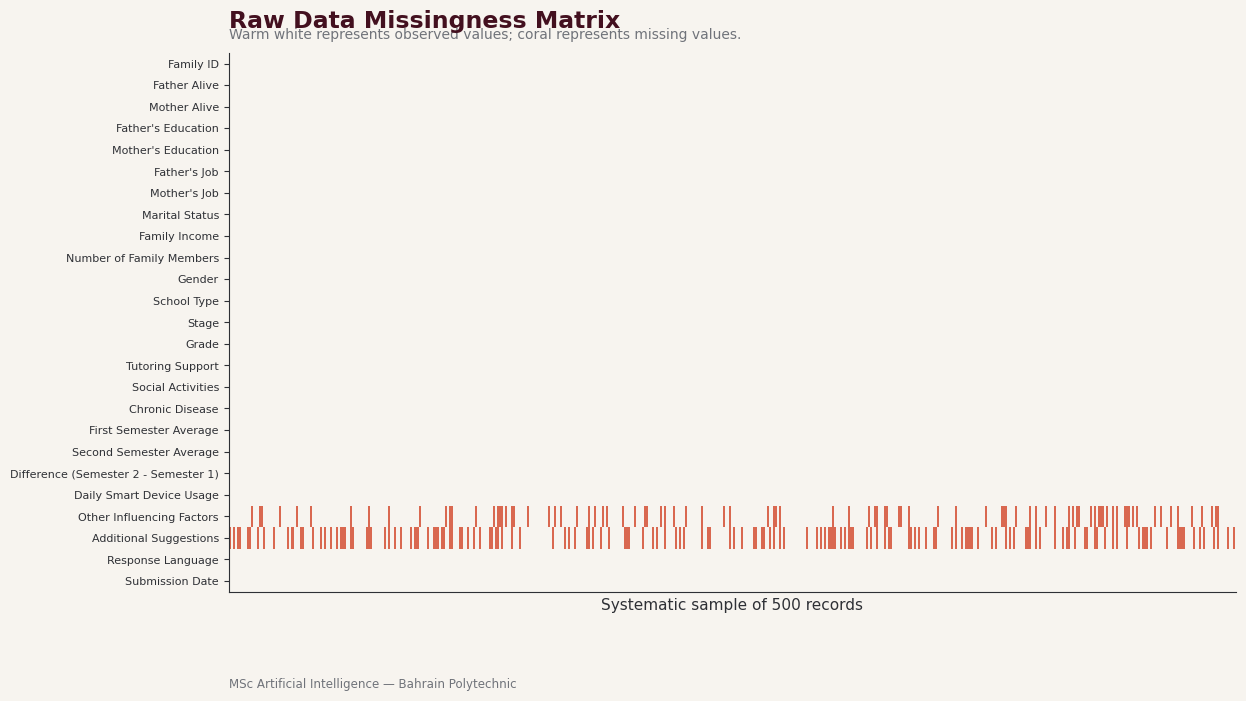

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_01_Project_Setup_and_Raw_Data_Understanding/Section_01_08_Multiple_Visualization_Raw_Data/Cell_01_08_01_Create_the_Missingness_Matrix/tables/01_08_01_missingness_data.csv'),
 WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_01_Project_Setup_and_Raw_Data_Understanding/Section_01_08_Multiple_Visualization_Raw_Data/Cell_01_08_01_Create_the_Missingness_Matrix/tables/01_08_01_missingness_data.xlsx')]

In [16]:
# Cell 1.8.1 — Create the Missingness Matrix

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_01", "Create_the_Missingness_Matrix",
)

sample_size = min(len(original_data), 500)
row_positions = np.linspace(0, len(original_data) - 1, sample_size).astype(int)
missing_matrix = original_data.iloc[row_positions].isna().astype(int).T

figure, axis = plt.subplots(figsize=(13, max(5, len(original_data.columns) * 0.28)))
cmap = ListedColormap([THEME["warm_white"], THEME["coral"]])
axis.imshow(missing_matrix, aspect="auto", interpolation="nearest", cmap=cmap)
axis.set_yticks(np.arange(len(original_data.columns)))
axis.set_yticklabels(original_data.columns, fontsize=8)
axis.set_xticks([])
axis.set_xlabel(f"Systematic sample of {sample_size:,} records")
add_branding(
    axis,
    "Raw Data Missingness Matrix",
    "Warm white represents observed values; coral represents missing values.",
)
figure_path = save_figure(figure, CELL_FOLDERS, "01_08_01_missingness_matrix")
plt.show()

save_dataframe(missing_values_report, CELL_FOLDERS, "01_08_01_missingness_data")

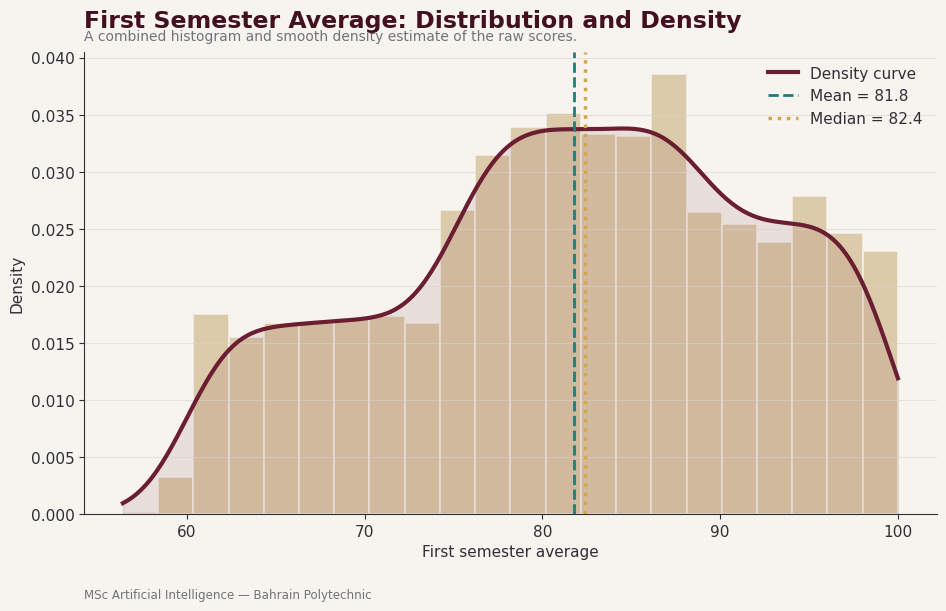

In [17]:
# Cell 1.8.2 — Create First-Semester Histogram and Density Curve

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_02", "Create_First_Semester_Histogram_and_Density_Curve",
)

column = locate_column(original_data, ["First Semester Average"])
if column is None:
    print("First Semester Average was not found; visualisation skipped.")
else:
    values = pd.to_numeric(original_data[column], errors="coerce").dropna()
    figure, axis = plt.subplots(figsize=(11, 6))
    axis.hist(values, bins=22, density=True, color=THEME["sand"], edgecolor=THEME["warm_white"], linewidth=1.2, alpha=0.9)
    if values.nunique() > 1:
        grid = np.linspace(values.min(), values.max(), 300)
        density = gaussian_kde(values)(grid)
        axis.plot(grid, density, color=THEME["maroon"], linewidth=3, label="Density curve")
        axis.fill_between(grid, density, color=THEME["maroon"], alpha=0.10)
    axis.axvline(values.mean(), color=THEME["teal"], linestyle="--", linewidth=2, label=f"Mean = {values.mean():.1f}")
    axis.axvline(values.median(), color=THEME["gold"], linestyle=":", linewidth=2.5, label=f"Median = {values.median():.1f}")
    axis.set_xlabel("First semester average")
    axis.set_ylabel("Density")
    axis.grid(axis="y")
    axis.legend()
    add_branding(axis, "First Semester Average: Distribution and Density", "A combined histogram and smooth density estimate of the raw scores.")
    save_figure(figure, CELL_FOLDERS, "01_08_02_first_semester_histogram_density")
    plt.show()

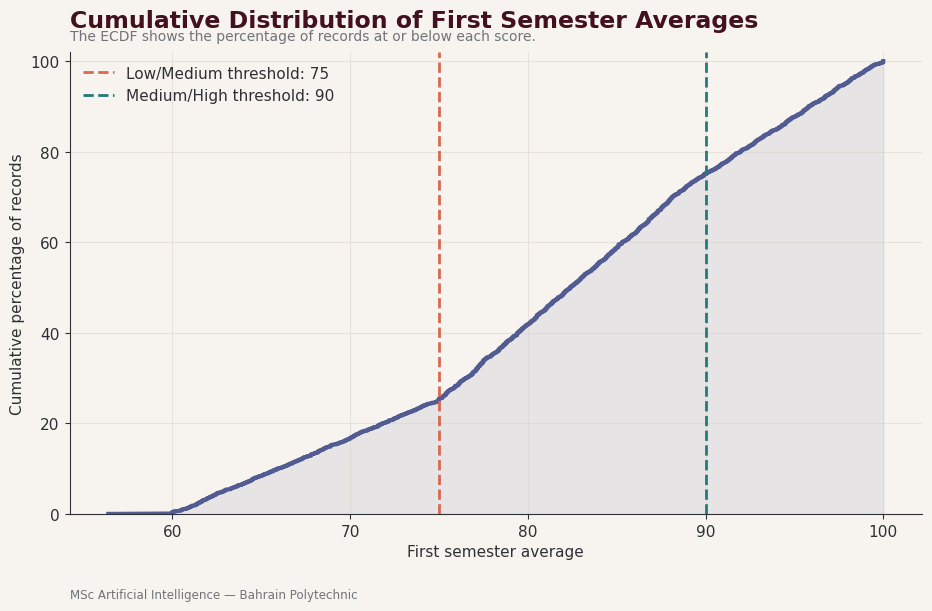

In [18]:
# Cell 1.8.3 — Create the First-Semester ECDF Line Chart

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_03", "Create_the_First_Semester_ECDF_Line_Chart",
)

column = locate_column(original_data, ["First Semester Average"])
if column is None:
    print("First Semester Average was not found; visualisation skipped.")
else:
    values = np.sort(pd.to_numeric(original_data[column], errors="coerce").dropna().to_numpy())
    cumulative = np.arange(1, len(values) + 1) / len(values) * 100
    figure, axis = plt.subplots(figsize=(11, 6))
    axis.plot(values, cumulative, color=THEME["indigo"], linewidth=3)
    axis.fill_between(values, cumulative, color=THEME["indigo"], alpha=0.10)
    axis.axvline(75, color=THEME["coral"], linestyle="--", linewidth=2, label="Low/Medium threshold: 75")
    axis.axvline(90, color=THEME["teal"], linestyle="--", linewidth=2, label="Medium/High threshold: 90")
    axis.set_xlabel("First semester average")
    axis.set_ylabel("Cumulative percentage of records")
    axis.set_ylim(0, 102)
    axis.grid(True)
    axis.legend()
    add_branding(axis, "Cumulative Distribution of First Semester Averages", "The ECDF shows the percentage of records at or below each score.")
    save_figure(figure, CELL_FOLDERS, "01_08_03_first_semester_ecdf")
    plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_11440\2964791982.py:14: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  violin = axis.violinplot(values, vert=False, showmeans=False, showmedians=False, showextrema=False)
C:\Users\User\AppData\Local\Temp\ipykernel_11440\2964791982.py:19: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(


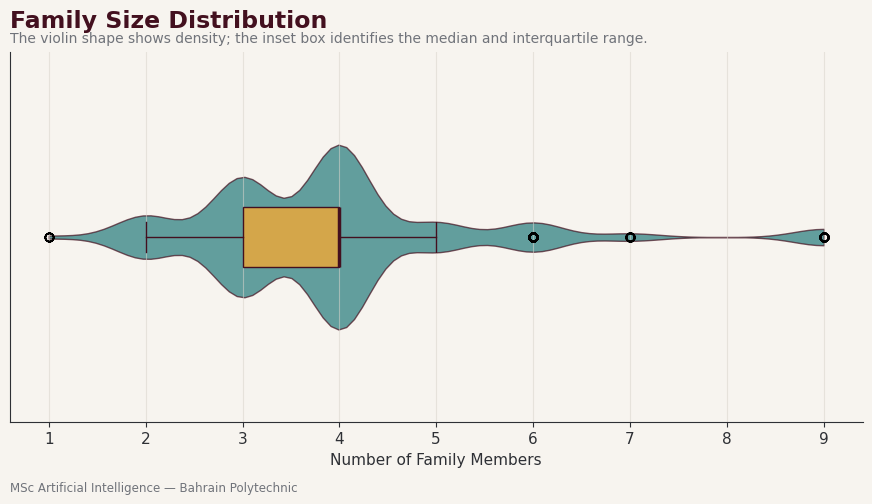

In [19]:
# Cell 1.8.4 — Create the Family-Size Violin Plot

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_04", "Create_the_Family_Size_Violin_Plot",
)

column = locate_column(original_data, ["Number of Family Members", "Number of Children in the Family"])
if column is None:
    print("Family-size variable was not found; visualisation skipped.")
else:
    values = pd.to_numeric(original_data[column], errors="coerce").dropna()
    figure, axis = plt.subplots(figsize=(11, 4.8))
    violin = axis.violinplot(values, vert=False, showmeans=False, showmedians=False, showextrema=False)
    for body in violin["bodies"]:
        body.set_facecolor(THEME["teal"])
        body.set_edgecolor(THEME["deep_maroon"])
        body.set_alpha(0.70)
    axis.boxplot(
        values, vert=False, widths=0.16, patch_artist=True,
        boxprops={"facecolor": THEME["gold"], "edgecolor": THEME["deep_maroon"]},
        medianprops={"color": THEME["deep_maroon"], "linewidth": 2.5},
        whiskerprops={"color": THEME["deep_maroon"]},
        capprops={"color": THEME["deep_maroon"]},
    )
    axis.set_yticks([])
    axis.set_xlabel(column)
    axis.grid(axis="x")
    add_branding(axis, "Family Size Distribution", "The violin shape shows density; the inset box identifies the median and interquartile range.")
    save_figure(figure, CELL_FOLDERS, "01_08_04_family_size_violin")
    plt.show()

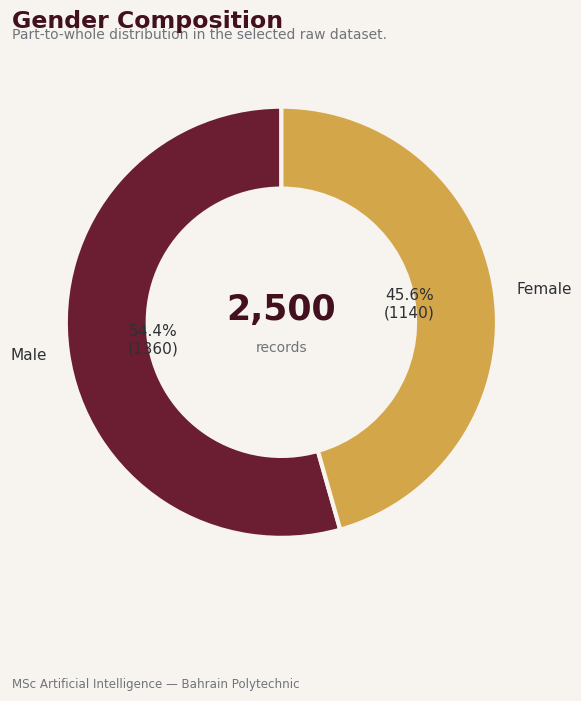

In [20]:
# Cell 1.8.5 — Create the Gender Donut Chart

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_05", "Create_the_Gender_Donut_Chart",
)

column = locate_column(original_data, ["Gender"])
if column is None:
    print("Gender was not found; visualisation skipped.")
else:
    counts = original_data[column].astype("string").fillna("<Missing>").value_counts()
    palette = [THEME["maroon"], THEME["gold"], THEME["teal"], THEME["coral"]][:len(counts)]
    figure, axis = plt.subplots(figsize=(8, 7))
    wedges, _, autotexts = axis.pie(
        counts.values,
        labels=counts.index,
        autopct=lambda pct: f"{pct:.1f}%\n({pct / 100 * counts.sum():.0f})",
        startangle=90,
        colors=palette,
        wedgeprops={"width": 0.38, "edgecolor": THEME["warm_white"], "linewidth": 3},
        textprops={"color": THEME["charcoal"]},
    )
    axis.text(0, 0.06, f"{counts.sum():,}", ha="center", va="center", fontsize=25, fontweight="bold", color=THEME["deep_maroon"])
    axis.text(0, -0.12, "records", ha="center", va="center", fontsize=10, color=THEME["muted"])
    add_branding(axis, "Gender Composition", "Part-to-whole distribution in the selected raw dataset.")
    save_figure(figure, CELL_FOLDERS, "01_08_05_gender_donut")
    plt.show()

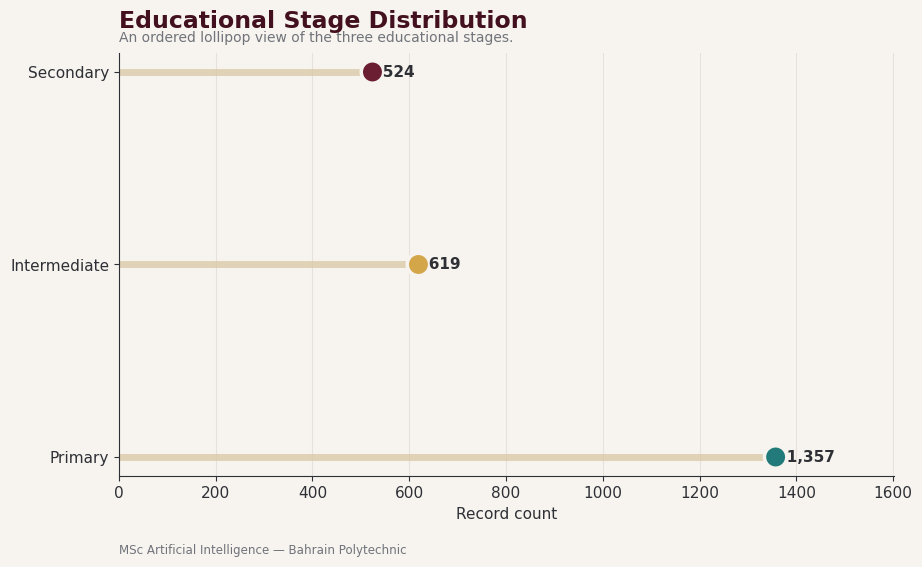

In [21]:
# Cell 1.8.6 — Create the Educational-Stage Lollipop Chart

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_06", "Create_the_Educational_Stage_Lollipop_Chart",
)

column = locate_column(original_data, ["Stage"])
if column is None:
    print("Stage was not found; visualisation skipped.")
else:
    order = [value for value in ["Primary", "Intermediate", "Secondary"] if value in set(original_data[column].dropna())]
    counts = original_data[column].value_counts().reindex(order).fillna(0)
    y = np.arange(len(counts))
    colours = [THEME["teal"], THEME["gold"], THEME["maroon"]][:len(counts)]
    figure, axis = plt.subplots(figsize=(10, 5.5))
    axis.hlines(y, 0, counts.values, color=THEME["sand"], linewidth=5, alpha=0.75)
    axis.scatter(counts.values, y, s=260, color=colours, edgecolor=THEME["warm_white"], linewidth=2.5, zorder=3)
    for position, value in zip(y, counts.values):
        axis.text(value, position, f"  {value:,.0f}", va="center", fontweight="bold")
    axis.set_yticks(y)
    axis.set_yticklabels(counts.index)
    axis.set_xlabel("Record count")
    axis.set_xlim(0, max(counts.values) * 1.18 if len(counts) else 1)
    axis.grid(axis="x")
    add_branding(axis, "Educational Stage Distribution", "An ordered lollipop view of the three educational stages.")
    save_figure(figure, CELL_FOLDERS, "01_08_06_stage_lollipop")
    plt.show()

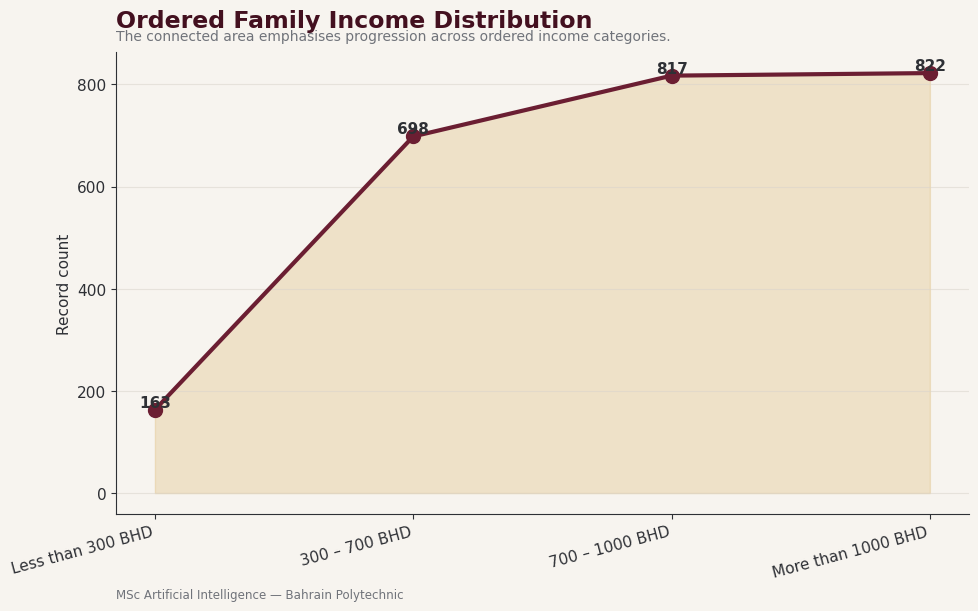

In [22]:
# Cell 1.8.7 — Create the Ordered Family-Income Chart

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_07", "Create_the_Ordered_Family_Income_Chart",
)

column = locate_column(original_data, ["Family Income"])
if column is None:
    print("Family Income was not found; visualisation skipped.")
else:
    income_order = ["Less than 300 BHD", "300 – 700 BHD", "700 – 1000 BHD", "More than 1000 BHD"]
    counts = original_data[column].value_counts().reindex(income_order).fillna(0)
    x = np.arange(len(counts))
    figure, axis = plt.subplots(figsize=(11, 6))
    axis.plot(x, counts.values, color=THEME["maroon"], linewidth=3, marker="o", markersize=10)
    axis.fill_between(x, counts.values, color=THEME["gold"], alpha=0.23)
    for xpos, value in zip(x, counts.values):
        axis.text(xpos, value, f"{value:,.0f}", ha="center", va="bottom", fontweight="bold")
    axis.set_xticks(x)
    axis.set_xticklabels(counts.index, rotation=15, ha="right")
    axis.set_ylabel("Record count")
    axis.grid(axis="y")
    add_branding(axis, "Ordered Family Income Distribution", "The connected area emphasises progression across ordered income categories.")
    save_figure(figure, CELL_FOLDERS, "01_08_07_family_income_ordered_area")
    plt.show()

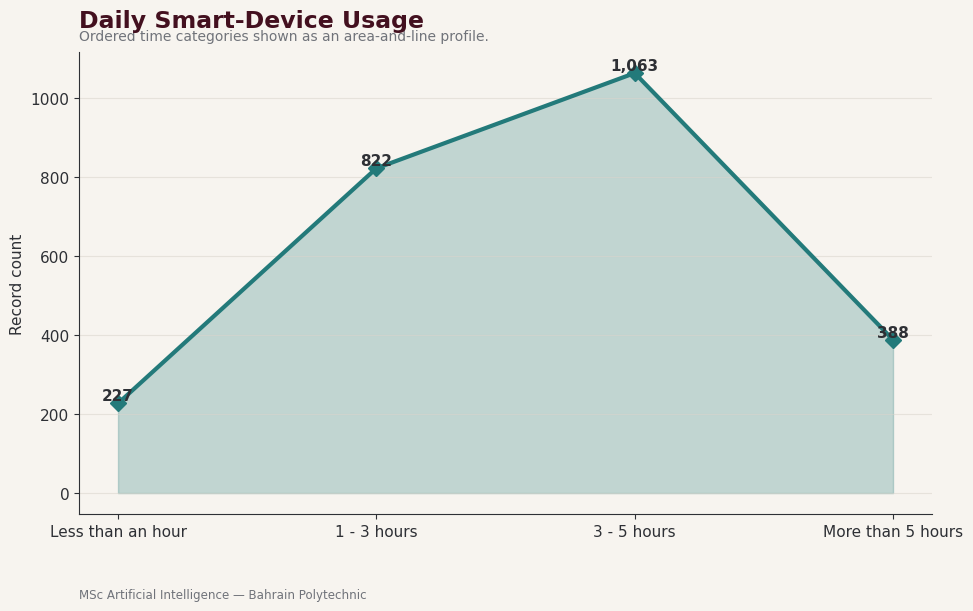

In [23]:
# Cell 1.8.8 — Create the Smart-Device Usage Area Chart

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_08", "Create_the_Smart_Device_Usage_Area_Chart",
)

column = locate_column(original_data, ["Daily Smart Device Usage"])
if column is None:
    print("Daily Smart Device Usage was not found; visualisation skipped.")
else:
    usage_order = ["Less than an hour", "1 - 3 hours", "3 - 5 hours", "More than 5 hours"]
    counts = original_data[column].value_counts().reindex(usage_order).fillna(0)
    x = np.arange(len(counts))
    figure, axis = plt.subplots(figsize=(11, 6))
    axis.fill_between(x, counts.values, color=THEME["teal"], alpha=0.25)
    axis.plot(x, counts.values, color=THEME["teal"], linewidth=3, marker="D", markersize=8)
    for xpos, value in zip(x, counts.values):
        axis.text(xpos, value, f"{value:,.0f}", ha="center", va="bottom", fontweight="bold")
    axis.set_xticks(x)
    axis.set_xticklabels(counts.index)
    axis.set_ylabel("Record count")
    axis.grid(axis="y")
    add_branding(axis, "Daily Smart-Device Usage", "Ordered time categories shown as an area-and-line profile.")
    save_figure(figure, CELL_FOLDERS, "01_08_08_device_usage_area")
    plt.show()

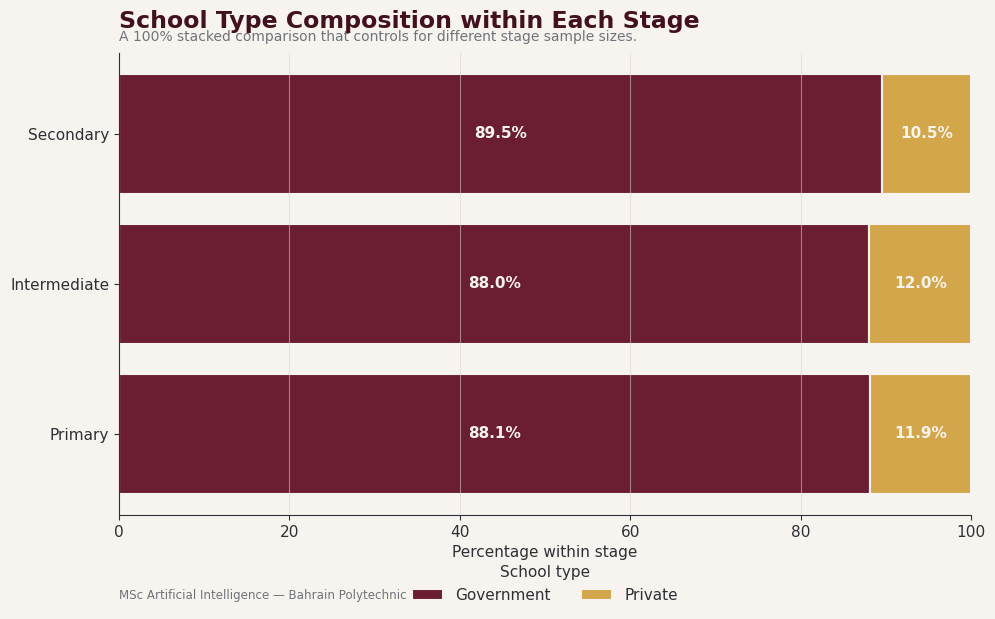

In [24]:
# Cell 1.8.9 — Create the Stage-by-School-Type Stacked Percentage Chart

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_09", "Create_the_Stage_by_School_Type_Stacked_Percentage_Chart",
)

stage_column = locate_column(original_data, ["Stage"])
school_column = locate_column(original_data, ["School Type"])
if stage_column is None or school_column is None:
    print("Stage or School Type was not found; visualisation skipped.")
else:
    stage_order = [value for value in ["Primary", "Intermediate", "Secondary"] if value in set(original_data[stage_column].dropna())]
    table = pd.crosstab(original_data[stage_column], original_data[school_column], normalize="index").reindex(stage_order).fillna(0) * 100
    figure, axis = plt.subplots(figsize=(11, 6))
    left = np.zeros(len(table))
    school_palette = {"Government": THEME["maroon"], "Private": THEME["gold"]}
    for school_type in table.columns:
        values = table[school_type].to_numpy()
        bars = axis.barh(table.index, values, left=left, label=school_type, color=school_palette.get(school_type, THEME["teal"]), edgecolor=THEME["warm_white"], linewidth=1.5)
        for bar, value, start in zip(bars, values, left):
            if value >= 7:
                axis.text(start + value / 2, bar.get_y() + bar.get_height()/2, f"{value:.1f}%", ha="center", va="center", color=THEME["warm_white"], fontweight="bold")
        left += values
    axis.set_xlim(0, 100)
    axis.set_xlabel("Percentage within stage")
    axis.legend(title="School type", ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.22))
    axis.grid(axis="x")
    add_branding(axis, "School Type Composition within Each Stage", "A 100% stacked comparison that controls for different stage sample sizes.")
    save_figure(figure, CELL_FOLDERS, "01_08_09_stage_school_type_stacked_percentage")
    plt.show()
    save_dataframe(table.reset_index(), CELL_FOLDERS, "01_08_09_stage_school_type_percentages")

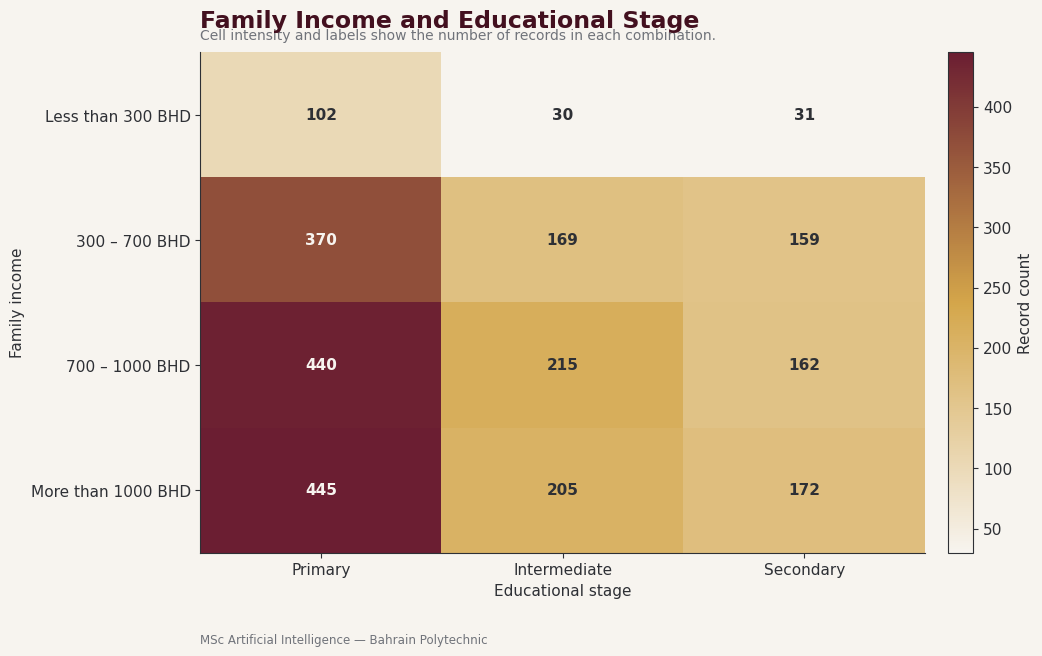

In [25]:
# Cell 1.8.10 — Create the Family-Income by Stage Heatmap

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_10", "Create_the_Family_Income_by_Stage_Heatmap",
)

income_column = locate_column(original_data, ["Family Income"])
stage_column = locate_column(original_data, ["Stage"])
if income_column is None or stage_column is None:
    print("Family Income or Stage was not found; visualisation skipped.")
else:
    income_order = ["Less than 300 BHD", "300 – 700 BHD", "700 – 1000 BHD", "More than 1000 BHD"]
    stage_order = ["Primary", "Intermediate", "Secondary"]
    table = pd.crosstab(original_data[income_column], original_data[stage_column]).reindex(index=income_order, columns=stage_order).fillna(0)
    custom_cmap = LinearSegmentedColormap.from_list("BahrainHeat", [THEME["warm_white"], THEME["gold"], THEME["maroon"]])
    figure, axis = plt.subplots(figsize=(10, 6.5))
    image = axis.imshow(table.values, cmap=custom_cmap, aspect="auto")
    axis.set_xticks(np.arange(len(table.columns)))
    axis.set_xticklabels(table.columns)
    axis.set_yticks(np.arange(len(table.index)))
    axis.set_yticklabels(table.index)
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            value = table.iloc[row, col]
            text_colour = THEME["warm_white"] if value > table.values.max() * 0.55 else THEME["charcoal"]
            axis.text(col, row, f"{value:,.0f}", ha="center", va="center", color=text_colour, fontweight="bold")
    colorbar = figure.colorbar(image, ax=axis, fraction=0.035, pad=0.03)
    colorbar.set_label("Record count")
    axis.set_xlabel("Educational stage")
    axis.set_ylabel("Family income")
    add_branding(axis, "Family Income and Educational Stage", "Cell intensity and labels show the number of records in each combination.")
    save_figure(figure, CELL_FOLDERS, "01_08_10_income_stage_heatmap")
    plt.show()
    save_dataframe(table.reset_index(), CELL_FOLDERS, "01_08_10_income_stage_crosstab")

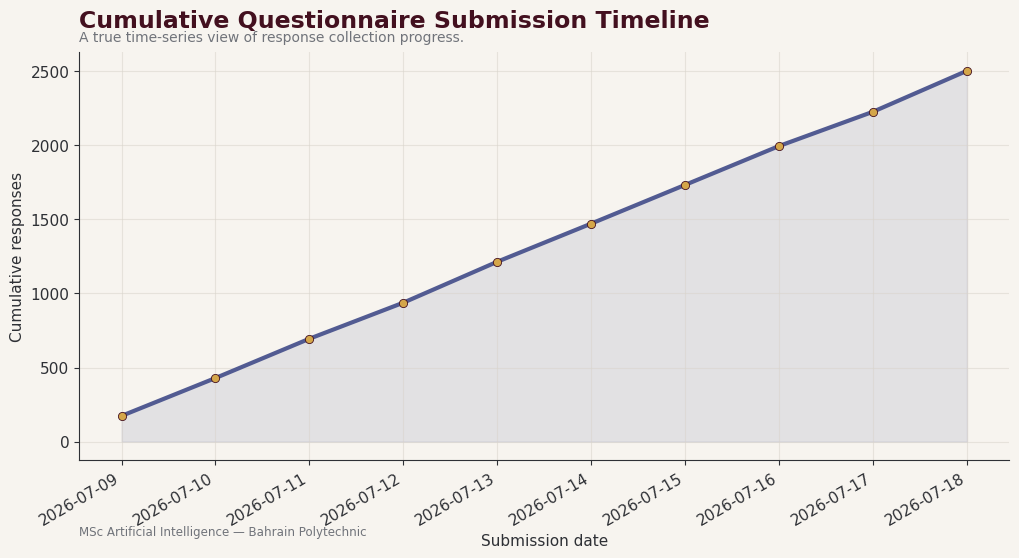

In [26]:
# Cell 1.8.11 — Create the Questionnaire Submission Timeline

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_11", "Create_the_Questionnaire_Submission_Timeline",
)

column = locate_column(original_data, ["Submission Date"])
if column is None:
    print("Submission Date was not found; visualisation skipped.")
else:
    dates = pd.to_datetime(original_data[column], errors="coerce").dropna()
    if dates.empty:
        print("Submission dates could not be parsed; visualisation skipped.")
    else:
        daily = dates.dt.floor("D").value_counts().sort_index()
        cumulative = daily.cumsum()
        figure, axis = plt.subplots(figsize=(12, 6))
        axis.plot(cumulative.index, cumulative.values, color=THEME["indigo"], linewidth=3)
        axis.fill_between(cumulative.index, cumulative.values, color=THEME["indigo"], alpha=0.12)
        axis.scatter(cumulative.index, cumulative.values, color=THEME["gold"], s=35, edgecolor=THEME["deep_maroon"], linewidth=0.6, zorder=3)
        axis.set_xlabel("Submission date")
        axis.set_ylabel("Cumulative responses")
        axis.grid(True)
        figure.autofmt_xdate()
        add_branding(axis, "Cumulative Questionnaire Submission Timeline", "A true time-series view of response collection progress.")
        save_figure(figure, CELL_FOLDERS, "01_08_11_submission_timeline")
        plt.show()
        save_dataframe(daily.rename_axis("submission_date").reset_index(name="daily_responses"), CELL_FOLDERS, "01_08_11_daily_submission_counts")

In [27]:
# Cell 1.8.12 — Create the Phase 1 Visualisation Catalogue

CELL_FOLDERS = create_cell_folders(
    "01_08", "Multiple_Visualization_Raw_Data",
    "01_08_12", "Create_the_Phase_1_Visualisation_Catalogue",
)

figure_files = sorted(PHASE_DIR.rglob("*.png"))
visualisation_catalogue = pd.DataFrame([
    {
        "figure_number": number,
        "figure_name": path.stem,
        "relative_path": str(path.relative_to(PHASE_DIR)),
        "file_size_kb": round(path.stat().st_size / 1024, 2),
    }
    for number, path in enumerate(figure_files, start=1)
])
save_dataframe(visualisation_catalogue, CELL_FOLDERS, "01_08_12_visualisation_catalogue")
print(f"Phase 1 figures created: {len(visualisation_catalogue)}")
display(visualisation_catalogue)

Phase 1 figures created: 19


,figure_number,figure_name,relative_path,file_size_kb
0,1,01_08_01_missingness_matrix,Section_01_08_Multiple_Visualization_Raw_Data\...,281.87
1,2,01_08_01_missing_values_raw_data,Section_01_08_Multiple_Visualization_Raw_Data\...,77.49
2,3,01_08_02_first_semester_histogram_density,Section_01_08_Multiple_Visualization_Raw_Data\...,228.46
3,4,01_08_02_first_semester_average,Section_01_08_Multiple_Visualization_Raw_Data\...,69.07
4,5,01_08_02_number_of_children_in_the_family,Section_01_08_Multiple_Visualization_Raw_Data\...,72.90
5,6,01_08_03_first_semester_ecdf,Section_01_08_Multiple_Visualization_Raw_Data\...,215.37
6,7,01_08_03_daily_smart_device_usage,Section_01_08_Multiple_Visualization_Raw_Data\...,87.19
7,8,01_08_03_family_income,Section_01_08_Multiple_Visualization_Raw_Data\...,80.74
8,9,01_08_03_gender,Section_01_08_Multiple_Visualization_Raw_Data\...,49.69
9,10,01_08_03_school_type,Section_01_08_Multiple_Visualization_Raw_Data\...,56.42


# Section 1.9 — Export Multiple Files and Phase Handoff

**Purpose:** Export a consolidated workbook, file manifest, phase summary, Phase 2 handoff manifest, and ZIP archive while retaining the full Phase → Section → Cell hierarchy.

In [28]:
# Cell 1.9.1 — Create the Phase 1 File Manifest

CELL_FOLDERS = create_cell_folders(
    "01_09", "Export_Multiple_Files_and_Phase_Handoff",
    "01_09_01", "Create_the_Phase_1_File_Manifest",
)

files_before_final_export = sorted(path for path in PHASE_DIR.rglob("*") if path.is_file())
phase_1_file_manifest = pd.DataFrame([
    {
        "file_number": number,
        "file_name": path.name,
        "extension": path.suffix.lower(),
        "relative_path": str(path.relative_to(PHASE_DIR)),
        "file_size_kb": round(path.stat().st_size / 1024, 2),
        "sha256": file_sha256(path),
        "last_modified": datetime.fromtimestamp(path.stat().st_mtime).isoformat(),
    }
    for number, path in enumerate(files_before_final_export, start=1)
])
save_dataframe(phase_1_file_manifest, CELL_FOLDERS, "01_09_01_phase_1_file_manifest")
display(phase_1_file_manifest)

,file_number,file_name,extension,relative_path,file_size_kb,sha256,last_modified
0,1,01_01_01_project_configuration.json,.json,Section_01_01_Project_Information_and_Executio...,0.81,81011d1fa5c2c2dfd00dcd30499e294a2a8f32d36c90c4...,2026-07-19T05:06:42.954531
1,2,01_01_01_project_configuration.json,.json,Section_01_01_Project_Information_and_Executio...,0.59,f6ea1863f98bf652d5aa8e5dbe1a8ef85710c43331c0e5...,2026-07-19T05:04:27.506780
2,3,01_02_01_library_installation_report.csv,.csv,Section_01_02_Install_Required_Libraries\Cell_...,0.20,6658913194fcabb8f8a5e0749fe6f664d1101f216402ca...,2026-07-19T05:06:42.995055
3,4,01_02_01_library_installation_report.xlsx,.xlsx,Section_01_02_Install_Required_Libraries\Cell_...,4.94,bf0a31e6e77e7e573437666905bfcdc974a002cf253c60...,2026-07-19T05:06:43.449701
4,5,01_03_01_reproducibility_settings.json,.json,Section_01_03_Import_Libraries_and_Reproducibi...,0.19,4d7244082ad13e95ed8df74f34a0aa3082db1d68fafcd7...,2026-07-19T05:04:28.306003
...,...,...,...,...,...,...,...
117,118,01_09_01_phase_1_file_manifest.xlsx,.xlsx,Section_01_09_Export_Multiple_Files\Cell_01_09...,7.85,83d2be7f6fc59000721cc59651f3d3f980b700f5b9d58d...,2026-07-19T05:04:33.472371
118,119,01_09_02_phase_1_consolidated_reports.xlsx,.xlsx,Section_01_09_Export_Multiple_Files\Cell_01_09...,23.81,5f0f7d9a159ec40b56b9a0875328fdd06ce1503c697060...,2026-07-19T05:04:33.599216
119,120,01_09_03_phase_1_complete_export.zip,.zip,Section_01_09_Export_Multiple_Files\Cell_01_09...,1010.29,154c95d2254e913fe66811beba088d25cd47b1c820f3f1...,2026-07-19T05:04:34.228677
120,121,01_09_03_phase_1_summary.json,.json,Section_01_09_Export_Multiple_Files\Cell_01_09...,0.72,9bb837dbd49b09609d825ce993e291da7838a68d4255b9...,2026-07-19T05:04:33.625932


In [29]:
# Cell 1.9.2 — Export the Consolidated Phase 1 Workbook

CELL_FOLDERS = create_cell_folders(
    "01_09", "Export_Multiple_Files_and_Phase_Handoff",
    "01_09_02", "Export_the_Consolidated_Phase_1_Workbook",
)

workbook_path = CELL_FOLDERS["files"] / "01_09_02_phase_1_consolidated_reports.xlsx"
workbook_tables = {
    "Project_Config": pd.DataFrame([project_configuration]),
    "Source_Registry": pd.DataFrame([{key: value for key, value in source_registry.items() if key != "phase_0_manifest"}]),
    "Data_Dictionary": approved_data_dictionary,
    "Schema_Summary": schema_summary,
    "Schema_Comparison": schema_comparison,
    "Dataset_Overview": dataset_overview,
    "Column_Profile": column_profile,
    "Numeric_Statistics": numeric_statistics,
    "Categorical_Stats": categorical_statistics,
    "Category_Frequencies": category_frequencies,
    "Missing_Values": missing_values_report,
    "Duplicate_Records": possible_duplicates,
    "Category_Issues": invalid_category_report,
    "Logic_Checks": numeric_logical_quality_report,
    "Visualisations": visualisation_catalogue,
    "File_Manifest": phase_1_file_manifest,
}

with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
    for sheet_name, table in workbook_tables.items():
        table.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Consolidated workbook:", workbook_path)

Consolidated workbook: C:\Users\User\Desktop\All\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding\Section_01_09_Export_Multiple_Files_and_Phase_Handoff\Cell_01_09_02_Export_the_Consolidated_Phase_1_Workbook\files\01_09_02_phase_1_consolidated_reports.xlsx


In [30]:
# Cell 1.9.3 — Create the Phase 2 Handoff Manifest and ZIP Archive

CELL_FOLDERS = create_cell_folders(
    "01_09", "Export_Multiple_Files_and_Phase_Handoff",
    "01_09_03", "Create_the_Phase_2_Handoff_Manifest_and_ZIP_Archive",
)

# Copy the principal handoff files into one clear location.
phase_2_input_csv = CELL_FOLDERS["files"] / "phase_01_raw_dataset_for_phase_02.csv"
phase_2_input_xlsx = CELL_FOLDERS["files"] / "phase_01_raw_dataset_for_phase_02.xlsx"
raw_data.to_csv(phase_2_input_csv, index=False, encoding="utf-8-sig")
raw_data.to_excel(phase_2_input_xlsx, index=False)

handoff_manifest = {
    "completed_phase": "Phase 1 — Project Setup and Raw Data Understanding",
    "next_phase": "Phase 2 — Data Cleaning and Feature Preparation",
    "data_source": DATA_SOURCE,
    "primary_input_for_phase_2": str(phase_2_input_csv.resolve()),
    "alternative_excel_input": str(phase_2_input_xlsx.resolve()),
    "source_file": str(SOURCE_FILE.resolve()),
    "source_file_sha256": file_sha256(SOURCE_FILE),
    "records": int(len(raw_data)),
    "source_columns": int(len(original_data.columns)),
    "audit_columns": int(len(raw_data.columns)),
    "technical_columns_added": ["student_record_id", "source_row_number"],
    "source_values_changed": 0,
    "records_deleted": 0,
    "preprocessing_applied": False,
    "exact_questionnaire_schema_match": bool(expected_columns == observed_columns),
    "phase_1_completed_at": datetime.now().isoformat(),
}
manifest_path = save_json_report(handoff_manifest, CELL_FOLDERS, "phase_01_handoff_manifest")

summary_text = f"""
PHASE 1 COMPLETION SUMMARY
{'=' * 72}
Project: {PROJECT_TITLE}
Student: {STUDENT_NAME} | ID: {STUDENT_ID}
Data source: {DATA_SOURCE}
Source file: {SOURCE_FILE.name}
Records: {len(original_data):,}
Source columns: {len(original_data.columns)}
Technical audit columns added: 2
Source values changed: 0
Records deleted: 0
Visualisations created: {len(visualisation_catalogue)}
Phase 2 input: {phase_2_input_csv}
Completed: {handoff_manifest['phase_1_completed_at']}
""".strip()
summary_path = CELL_FOLDERS["reports"] / "01_09_03_phase_1_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")

zip_path = CELL_FOLDERS["files"] / "01_09_03_phase_1_complete_export.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(PHASE_DIR.rglob("*")):
        if path.is_file() and path != zip_path:
            archive.write(path, path.relative_to(PHASE_DIR))

print(summary_text)
print("\nHandoff manifest:", manifest_path)
print("ZIP archive:", zip_path)

PHASE 1 COMPLETION SUMMARY
Project: Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain
Student: Jaafar Ahmed | ID: 202508989
Data source: SYNTHETIC
Source file: synthetic_questionnaire_results_2500_records.csv
Records: 2,500
Source columns: 25
Technical audit columns added: 2
Source values changed: 0
Records deleted: 0
Visualisations created: 19
Phase 2 input: C:\Users\User\Desktop\All\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding\Section_01_09_Export_Multiple_Files_and_Phase_Handoff\Cell_01_09_03_Create_the_Phase_2_Handoff_Manifest_and_ZIP_Archive\files\phase_01_raw_dataset_for_phase_02.csv
Completed: 2026-07-19T05:06:58.118577

Handoff manifest: C:\Users\User\Desktop\All\outputs\Phase_01_Project_Setup_and_Raw_Data_Understanding\Section_01_09_Export_Multiple_Files_and_Phase_Handoff\Cell_01_09_03_Create_the_Phase_2_Handoff_Manifest_and_ZIP_Archive\reports\phase_01_handoff_manifest.json
ZIP archi

# Phase 1 Completed

The selected dataset has been loaded, preserved, documented, quality-checked, and visualised without preprocessing. Phase 2 should read `phase_01_handoff_manifest.json` and begin cleaning from the exported raw audit dataset.